In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


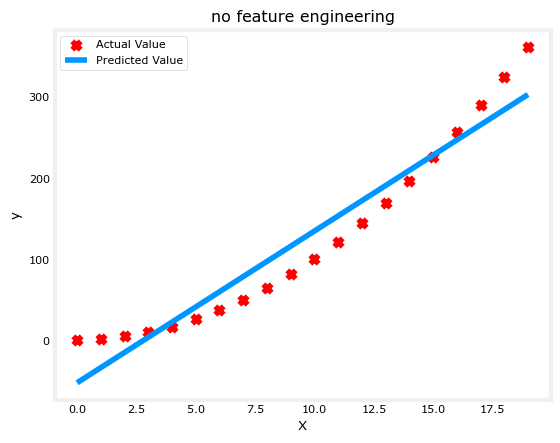

In [ ]:
#polynomial features
#using the 𝑦=1+𝑥**2 ---> quadratic equation
from re import A


x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

model_w, model_b = run_gradient_descent_feng(X, y, iterations=1000, alpha=1e-2)

plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title('no feature engineering')
plt.plot(x, X@model_w + model_b, label='Predicted Value'); plt.xlabel('X'); plt.ylabel('y'); plt.legend();plt.show()

In [ ]:
#observation: Not a great fit

In [5]:
#modifying the input to fit a polynomial feature
#create target value
x = np.arange(0, 20, 1)
y = 1 + x**2

#engineer features
X = x**2   #added engineered feature

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.], b: 0.0490


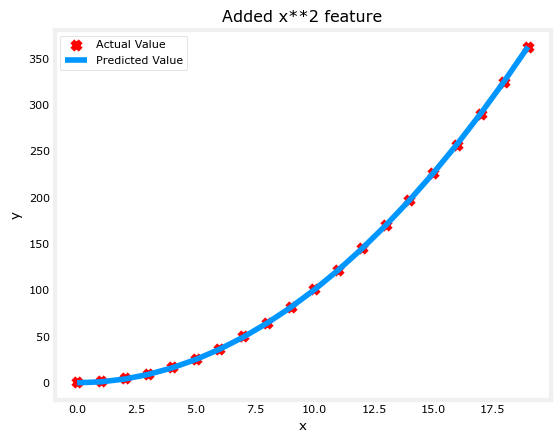

In [6]:
X = X.reshape(-1, 1)   #`X` should be a 2-D matrix
model_w, model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha=1e-5)

plt.scatter(x, y, marker='x', c='r',label='Actual Value'); plt.title('Added x**2 feature')
plt.plot(x, np.dot(X, model_w) + model_b, label='Predicted Value')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


In [ ]:
#observation: Near perfect fit
#this is the model of y = 1 * (x**2) + 0.049 --->(y = wx + b)

In [7]:
#selecting features
# lets try 𝑦=𝑤0𝑥0 + 𝑤1(𝑥**2)1 + 𝑤2(𝑥**3)2 + 𝑏 ---> polynomial expression
#create target data

x = np.arange(0, 20, 1)
y = x**2 

#engineer features
X = np.c_[x, x**2, x**3]   #added engineered features


Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08 0.54 0.03], b: 0.0106


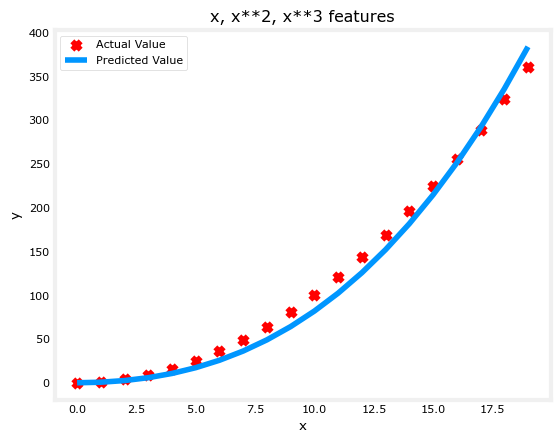

In [9]:
from cProfile import label


model_w, model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha=1e-7)

plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title('x, x**2, x**3 features')
plt.plot(x, X@model_w + model_b, label='Predicted Value'); plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.show()


In [ ]:
#observation: this fits the polynomial---> 0.08x + 0.54(x**2) + 0.03(x**3) + 0.01.6
#  w[0.08, 0.54, 0.03], b[0.01.6]
# from the two polynomial equations, the quadratic y=(x**2) + b --> 1*(x**2) + 0.0490 fits better
#    w[1], b[0.0490]
#
#less weight implies less important/correct features. As the weight approaches zero,
#  the associated feature is not useful in fitting the model. Therefore, in the 
# above polynomial, the feature associated with (x**2)-->0.54 weighs much larger than x, or (x**3), 
# and it is most useful in fitting the data 

In [10]:
#alternate view
#create target data
x = np.arange(0, 20, 1)
y = x**2

#engineer features
X = np.c_[x, x**2, x**3] # added engineered features
X_features = ['x', 'x^2', 'x^3']


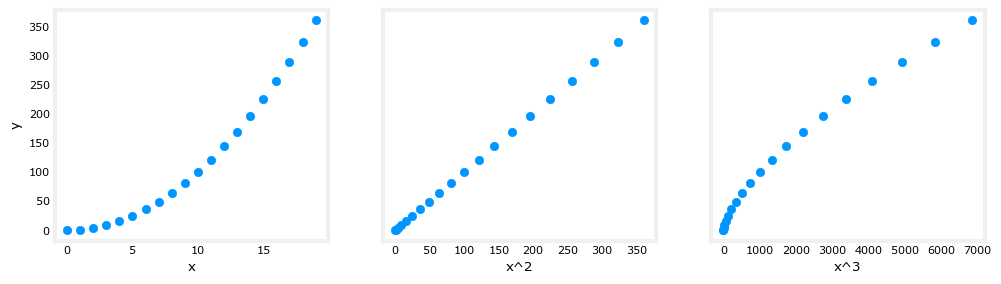

In [11]:
fig, ax=plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i], y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('y')
plt.show()

In [ ]:
#observation: it is clear  the feature associated with `x^2` mapped against the target value y is linear

In [12]:
#scaling features - speeds up the gradient descent
#z-score normalization
#create target features
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f'Peak to Peak range column in Raw           X:{np.ptp(X, axis=0)}')

#add mean_normalization
X = zscore_normalize_features(X)
print(f'Peak to Peak range by column in Normalized X:{np.ptp(X, axis=0)}')


Peak to Peak range column in Raw           X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.3  3.18 3.28]


Iteration         0, Cost: 9.42147e+03
Iteration     10000, Cost: 3.90938e-01
Iteration     20000, Cost: 2.78389e-02
Iteration     30000, Cost: 1.98242e-03
Iteration     40000, Cost: 1.41169e-04
Iteration     50000, Cost: 1.00527e-05
Iteration     60000, Cost: 7.15855e-07
Iteration     70000, Cost: 5.09763e-08
Iteration     80000, Cost: 3.63004e-09
Iteration     90000, Cost: 2.58497e-10
w,b found by gradient descent: w: [5.27e-05 1.13e+02 8.43e-05], b: 123.5000


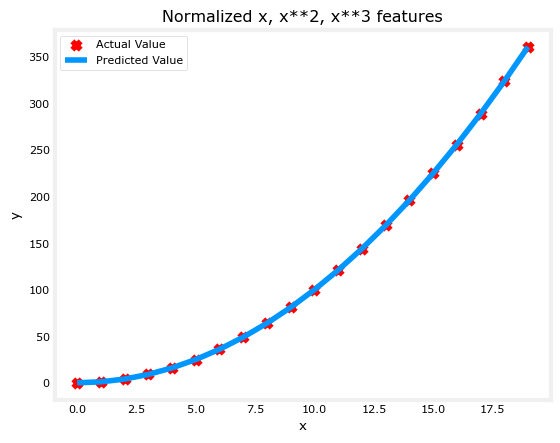

In [14]:
#using a more aggressive alpha value
x = np.arange(0, 20, 1)
y = x**2

X = np.c_[x, x**2, x**3]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X, y, iterations=100000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title('Normalized x, x**2, x**3 features')
plt.plot(x, X@model_w + model_b, label='Predicted Value')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

In [ ]:
#Feature scaling allows for the gradient descent to converge much faster
# The feature with `x^2` is the most emphasized 
# the feature with `x^3` has been eliminated cos it's very low

Iteration         0, Cost: 2.24887e-01
Iteration    100000, Cost: 2.31061e-02
Iteration    200000, Cost: 1.83619e-02
Iteration    300000, Cost: 1.47950e-02
Iteration    400000, Cost: 1.21114e-02
Iteration    500000, Cost: 1.00914e-02
Iteration    600000, Cost: 8.57025e-03
Iteration    700000, Cost: 7.42385e-03
Iteration    800000, Cost: 6.55908e-03
Iteration    900000, Cost: 5.90594e-03
w,b found by gradient descent: w: [-1.61e+00 -1.01e+01  3.00e+01 -6.92e-01 -2.37e+01 -1.51e+01  2.09e+01
 -2.29e-03 -4.69e-03  5.51e-02  1.07e-01 -2.53e-02  6.49e-02], b: -0.0073


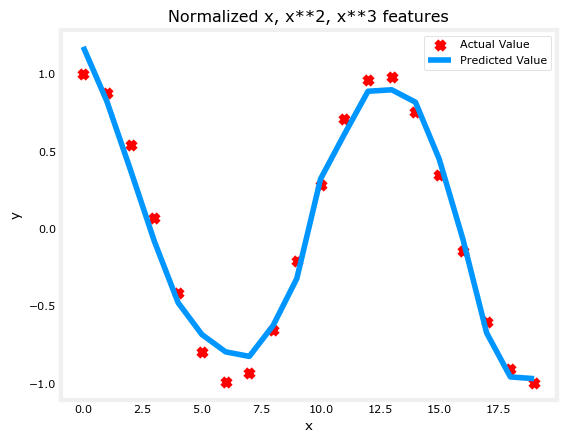

In [ ]:
#we try complex features
x = np.arange(0, 20, 1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X, y, iterations=1000000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title('Normalized x, x**2, x**3 features')
plt.plot(x, X@model_w + model_b, label='Predicted Value')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()